# Movie Ratings Analysis of websites

In this project, our main objective is to find discrepancy between the number of star displayed to user  and actual star rating of Fandango(an online movie ratings aggregator.
- Hickey found that there was a significant discrepancy between the number of stars displayed to user and the acutal rating, which he was able to find in the `HTML` of the page.

- we will analyze more movie ratings data to determine whether there was any change in Fandango's rating system after Hickey's analysis

## Exploring the relevant dataset

In [1]:
# import necessary module for analyis

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Read the rating file before correction

old_data = pd.read_csv('../../dataset/fandango_score_comparison.csv')
old_data.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Fandango_Stars,Fandango_Ratingvalue,RT_norm,RT_user_norm,...,IMDB_norm,RT_norm_round,RT_user_norm_round,Metacritic_norm_round,Metacritic_user_norm_round,IMDB_norm_round,Metacritic_user_vote_count,IMDB_user_vote_count,Fandango_votes,Fandango_Difference
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,5.0,4.5,3.70,4.3,...,3.90,3.5,4.5,3.5,3.5,4.0,1330,271107,14846,0.5
1,Cinderella (2015),85,80,67,7.5,7.1,5.0,4.5,4.25,4.0,...,3.55,4.5,4.0,3.5,4.0,3.5,249,65709,12640,0.5
2,Ant-Man (2015),80,90,64,8.1,7.8,5.0,4.5,4.00,4.5,...,3.90,4.0,4.5,3.0,4.0,4.0,627,103660,12055,0.5
3,Do You Believe? (2015),18,84,22,4.7,5.4,5.0,4.5,0.90,4.2,...,2.70,1.0,4.0,1.0,2.5,2.5,31,3136,1793,0.5
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,3.5,3.0,0.70,1.4,...,2.55,0.5,1.5,1.5,1.5,2.5,88,19560,1021,0.5


In [3]:
# check the shape of data
old_data.shape

(146, 22)

In [4]:
old_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Fandango_Stars              146 non-null    float64
 7   Fandango_Ratingvalue        146 non-null    float64
 8   RT_norm                     146 non-null    float64
 9   RT_user_norm                146 non-null    float64
 10  Metacritic_norm             146 non-null    float64
 11  Metacritic_user_nom         146 non-null    float64
 12  IMDB_norm                   146 non-null    float64
 13  RT_norm_round               146 non

We can see the dataset doesn't contain any null values.

In [5]:
# Read the new dataset after fixture
new_data = pd.read_csv('../../dataset/movie_ratings_16_17.csv')
new_data.head()

,movie,year,metascore,imdb,tmeter,audience,fandango,n_metascore,n_imdb,n_tmeter,n_audience,nr_metascore,nr_imdb,nr_tmeter,nr_audience
0,10 Cloverfield Lane,2016,76,7.2,90,79,3.5,3.80,3.60,4.50,3.95,4.0,3.5,4.5,4.0
1,13 Hours,2016,48,7.3,50,83,4.5,2.40,3.65,2.50,4.15,2.5,3.5,2.5,4.0
2,A Cure for Wellness,2016,47,6.6,40,47,3.0,2.35,3.30,2.00,2.35,2.5,3.5,2.0,2.5
3,A Dog's Purpose,2017,43,5.2,33,76,4.5,2.15,2.60,1.65,3.80,2.0,2.5,1.5,4.0
4,A Hologram for the King,2016,58,6.1,70,57,3.0,2.90,3.05,3.50,2.85,3.0,3.0,3.5,3.0


In [6]:
new_data.shape

(214, 15)

In [7]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie         214 non-null    object 
 1   year          214 non-null    int64  
 2   metascore     214 non-null    int64  
 3   imdb          214 non-null    float64
 4   tmeter        214 non-null    int64  
 5   audience      214 non-null    int64  
 6   fandango      214 non-null    float64
 7   n_metascore   214 non-null    float64
 8   n_imdb        214 non-null    float64
 9   n_tmeter      214 non-null    float64
 10  n_audience    214 non-null    float64
 11  nr_metascore  214 non-null    float64
 12  nr_imdb       214 non-null    float64
 13  nr_tmeter     214 non-null    float64
 14  nr_audience   214 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 25.2+ KB


In [8]:
# Isolate the required column for analysis in new variable
previous_rating = old_data[['FILM', 'Fandango_Stars', 'Fandango_Ratingvalue', 'Fandango_votes', 'Fandango_Difference']].copy()

In [9]:
new_rating = new_data[['movie', 'year', 'fandango']]

The sampling processes used for collection of both dataset were not random, and the resulting sample are very unlikey to be representative of the population we're intrested in describing.
- we will tweek our goal for this analysis so that it can act as good proxy for our initial goal
- we will analyze the rating of movies released in 2015 and 2016 and find out whether there's any difference between Fandango's ratings.
- With this new goal , we not have two poulations that we want to describe and compare to


## Isolate the movies released in 2015 and 2016 from the datasets

In [15]:
# isloate the 2015 movies
previous_rating['years'] = previous_rating['FILM'].str[-5:-1]
previous_rating['years'].head()


0    2015
1    2015
2    2015
3    2015
4    2015
Name: years, dtype: object

In [16]:
movie_2015 = previous_rating[previous_rating['years'] == '2015']
movie_2015.head()

,FILM,Fandango_Stars,Fandango_Ratingvalue,Fandango_votes,Fandango_Difference,years
0,Avengers: Age of Ultron (2015),5.0,4.5,14846,0.5,2015
1,Cinderella (2015),5.0,4.5,12640,0.5,2015
2,Ant-Man (2015),5.0,4.5,12055,0.5,2015
3,Do You Believe? (2015),5.0,4.5,1793,0.5,2015
4,Hot Tub Time Machine 2 (2015),3.5,3.0,1021,0.5,2015


In [17]:
print(movie_2015.shape)

(129, 6)


In [18]:
# isolating 2016 movies 

movie_2016 = new_rating[new_rating['year'] == 2016]
movie_2016.head()

,movie,year,fandango
0,10 Cloverfield Lane,2016,3.5
1,13 Hours,2016,4.5
2,A Cure for Wellness,2016,3.0
4,A Hologram for the King,2016,3.0
5,A Monster Calls,2016,4.0


In [19]:
movie_2016.shape

(191, 3)

## Comparing distribution shapes for 2015 and 2016

In [24]:
import seaborn as sns
%matplotlib inline

In [25]:
plt.style.use('fivethirtyeight')

In [29]:
import numpy as np

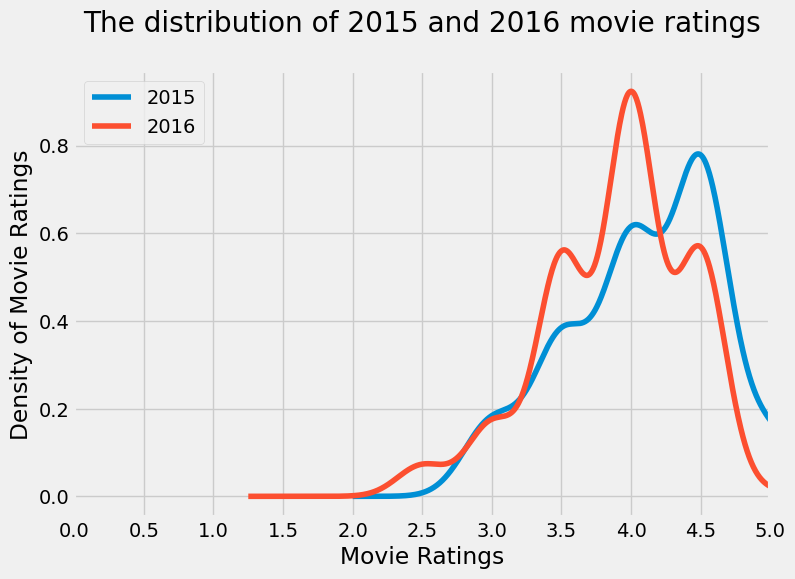

In [31]:
movie_2015['Fandango_Stars'].plot.kde(label = '2015', legend = True ,figsize = (8,5.5))
movie_2016['fandango'].plot.kde(label = '2016', legend = True)
plt.xlim(0, 5)
plt.xticks(np.arange(0,5.1,.5))
plt.title('The distribution of 2015 and 2016 movie ratings', y = 1.07)
plt.xlabel('Movie Ratings')
plt.ylabel('Density of Movie Ratings')
plt.show()

Important analysis from the graph
- Both of the graphs are `left skewed`
- In 2016, there is slightly `low` rating compared to 2015, which can be the result of the investigation.
- `2016` has higher 4 star rating as compared to 2015

## Comparing Relative Frequencies

In [40]:
movie_2015['Fandango_Stars'].value_counts(normalize = True).sort_index() * 100

Fandango_Stars
3.0     8.527132
3.5    17.829457
4.0    28.682171
4.5    37.984496
5.0     6.976744
Name: proportion, dtype: float64

In [41]:
movie_2016['fandango'].value_counts(normalize = True).sort_index() * 100

fandango
2.5     3.141361
3.0     7.329843
3.5    24.083770
4.0    40.314136
4.5    24.607330
5.0     0.523560
Name: proportion, dtype: float64

Relative frequencies is more common to use here as compared to absolute frequencies.

In 2015, there are `~7%`with 5 star rating , but in 2016, there are less than `1%`
- Also , `37%` of the movies are rated 4.5 stars as compared to `24%` which show `13%` difference.


## Determining the Direction of the Change

In [43]:
mean_2015 = movie_2015['Fandango_Stars'].mean()
median_2015 = movie_2015['Fandango_Stars'].median()
mode_2015 = movie_2015['Fandango_Stars'].mode()[0]

mean_2016 = movie_2016['fandango'].mean()
median_2016 = movie_2016['fandango'].median()
mode_2016 = movie_2016['fandango'].mode()[0]

summary = pd.DataFrame()
summary['2015'] = [mean_2015, median_2015, mode_2015]
summary['2016'] = [mean_2016, median_2016, mode_2016]
summary.index = ['mean', 'median', 'mode']
summary

,2015,2016
mean,4.085271,3.887435
median,4.000000,4.000000
mode,4.500000,4.000000


From the frequency table, we can see the mean rating decreasaed by `0.2` in 2016 compared to 2015

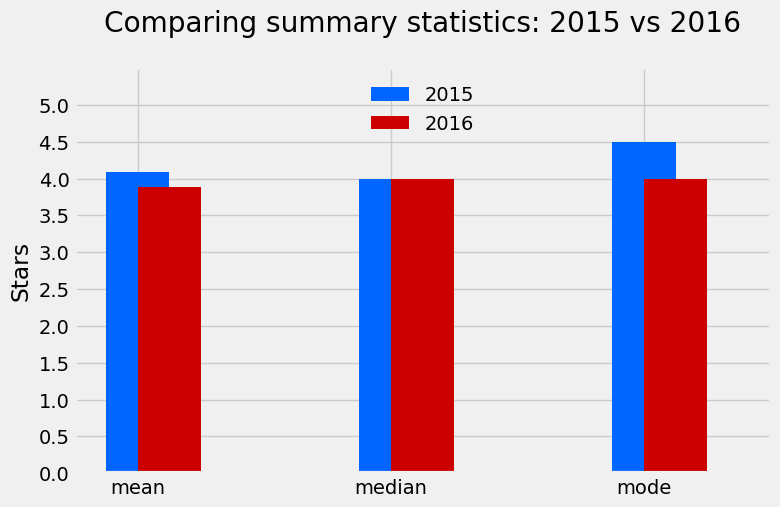

In [46]:
plt.style.use('fivethirtyeight')
summary['2015'].plot.bar(color = '#0066FF', align = 'center', label = '2015', width = .25)
summary['2016'].plot.bar(color = '#CC0000', align = 'edge', label = '2016', width = .25,
                         rot = 0, figsize = (8,5))

plt.title('Comparing summary statistics: 2015 vs 2016', y = 1.07)
plt.ylim(0,5.5)
plt.yticks(np.arange(0,5.1,.5))
plt.ylabel('Stars')
plt.legend(framealpha = 0, loc = 'upper center')
plt.show()